<a href="https://colab.research.google.com/github/sangitabehera103-ops/sangitabehera/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [80]:
df = data
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [81]:
# Display first 5 rows
print("First 5 Rows:")
print(df.head())

First 5 Rows:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  median_house_value  
0      1015.0       472.0         1.4936             66900.0  
1      1129.0       463.0         1.8200             80100.0  
2       333.0       117.0         1.6509             85700.0  
3       515.0       226.0         3.1917             73400.0  
4       624.0       262.0         1.9250             65500.0  


In [82]:
# Shape of dataset
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(17000, 9)


In [83]:
# Column names
print("\nColumns:")
print(df.columns.tolist())


Columns:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']


In [84]:
# Data types
print("\nData Types:")
print(df.dtypes)


Data Types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
dtype: object


In [85]:
# Numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("\nNumerical Columns:")
print(numerical_cols)
print("\ncategorical columns")
print(categorical_cols)


Numerical Columns:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']

categorical columns
[]


In [86]:
# Further classification of numerical columns
discrete_cols = []
continuous_cols = []

for col in numerical_cols:
    if df[col].dtype == 'int64':
        discrete_cols.append(col)
    else:
        continuous_cols.append(col)

print("\nDiscrete Numerical Columns:")
print(discrete_cols)

print("\nContinuous Numerical Columns:")
print(continuous_cols)


Discrete Numerical Columns:
[]

Continuous Numerical Columns:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']


In [87]:
# Nominal and Ordinal categorical columns
# (By domain knowledge; Airbnb dataset has no obvious ordinal variables)

nominal_cols = categorical_cols
ordinal_cols = []

print("\nNominal Categorical Columns:")
print(nominal_cols)

print("\nOrdinal Categorical Columns:")
print(ordinal_cols)



Nominal Categorical Columns:
[]

Ordinal Categorical Columns:
[]


In [88]:
# Count missing values
missing_count = df.isnull().sum()

# Percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

In [89]:
# Create summary table
missing_summary = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage (%)': missing_percentage
})

In [90]:
# Display only columns with missing values
missing_summary = missing_summary[missing_summary['Missing Values'] > 0]

print("\nMissing Values Summary:")
print(missing_summary.sort_values(by='Percentage (%)', ascending=False))


Missing Values Summary:
Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []


In [91]:
print("\nUpdated Dataset Shape:")
print(df.shape)


Updated Dataset Shape:
(17000, 9)


In [92]:
print("\nRemaining Columns:")
print(df.columns.tolist())


Remaining Columns:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']


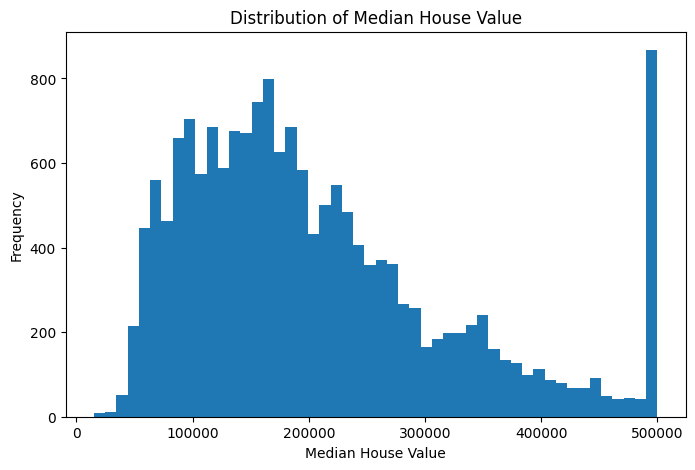

In [93]:
import matplotlib.pyplot as plt

# Histogram for Price (using 'median_house_value')
plt.figure(figsize=(8,5))
plt.hist(df['median_house_value'], bins=50)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()

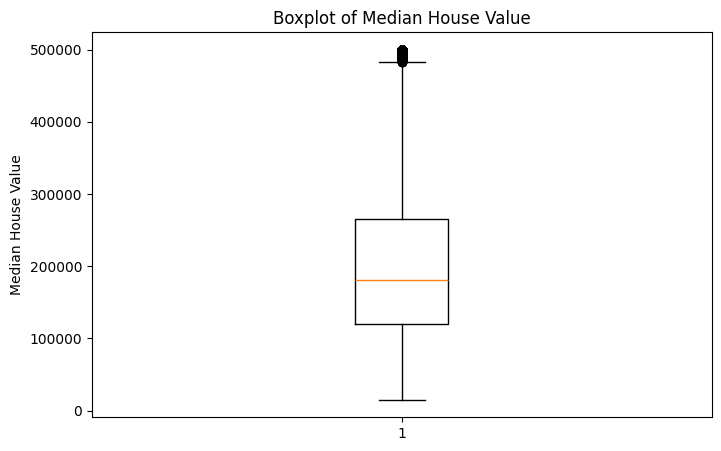

In [94]:
# Boxplot for Price
plt.figure(figsize=(8,5))
plt.boxplot(df['median_house_value'])
plt.title('Boxplot of Median House Value')
plt.ylabel('Median House Value')
plt.show()

In [95]:
# The 'minimum_nights' column was not found in the DataFrame. No histogram can be plotted for this column.

In [96]:
# Check original shape
print("Original Dataset Shape:", df.shape)


Original Dataset Shape: (17000, 9)


In [97]:
# Calculate 95th percentile thresholds
price_cap = df['median_house_value'].quantile(0.95)
# minimum_nights_cap = df['minimum_nights'].quantile(0.95) # This column does not exist

print("\n95th Percentile for Median House Value:", price_cap)
# print("95th Percentile for Minimum Nights:", minimum_nights_cap)


95th Percentile for Median House Value: 495500.0


In [98]:
# Trim records above 95th percentile
df = df[
    (df['median_house_value'] <= price_cap)
    # The 'minimum_nights' column does not exist in this dataset, so this condition is removed.
]

print("\nDataset Shape After 95th Percentile Trimming:")
print(df.shape)


Dataset Shape After 95th Percentile Trimming:
(16151, 9)


In [99]:
# Check number of unique values
# The 'neighbourhood' column does not exist in this dataset.
# print("Unique values in neighbourhood:")
# print(df['neighbourhood'].nunique())

# The 'neighbourhood_group' column does not exist in this dataset.
# print("\nUnique values in neighbourhood_group:")
# print(df['neighbourhood_group'].nunique())

In [100]:
# Drop high-cardinality column
# df.drop('neighbour', axis=1, inplace=True) # The 'neighbour' column does not exist in this dataset.

# print("\n'neighbourhood' column dropped.") # This message is also not applicable as the column does not exist.

print("\nRemaining Columns:")
print(df.columns.tolist())


Remaining Columns:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']


In [101]:
## Encode categorical variables
# df = pd.get_dummies(
#     df,
#     columns=['neighbourhood_group', 'room_type'],
#     drop_first=True
# )

In [102]:
print("\nEncoded Columns:")
print(df.columns.tolist())


Encoded Columns:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']


In [103]:
# Features
X = df.drop('median_house_value', axis=1)

# Target variable
y = df['median_house_value']

print("Shape of Features (X):", X.shape)
print("Shape of Target (y):", y.shape)

Shape of Features (X): (16151, 8)
Shape of Target (y): (16151,)


In [104]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Feature Shape:", X_train.shape)
print("Testing Feature Shape:", X_test.shape)

print("\nTraining Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)


Training Feature Shape: (12920, 8)
Testing Feature Shape: (3231, 8)

Training Target Shape: (12920,)
Testing Target Shape: (3231,)


In [105]:
from sklearn.linear_model import LinearRegression

# Initialize model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [106]:
# Predict prices on testing data
y_pred = lr_model.predict(X_test)

print("\nFirst 10 Predictions:")
print(y_pred[:10])


First 10 Predictions:
[201282.19579106 189399.79855918 263863.13525938 263114.63634068
 200631.4801838  155234.1925314  152089.82720204 210180.47081071
 259455.07953938 205779.19242347]


In [107]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# R-Squared
r2 = r2_score(y_test, y_pred)


In [108]:
# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

In [109]:
# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error
rmse = mse ** 0.5

print("\n========== MODEL PERFORMANCE ==========")
print(f"R² Score  : {r2:.4f}")
print(f"MAE       : ${mae:.2f}")
print(f"MSE       : {mse:.2f}")
print(f"RMSE      : ${rmse:.2f}")


========== MODEL PERFORMANCE ==========
R² Score  : 0.6179
MAE       : $44791.01
MSE       : 3559856182.58
RMSE      : $59664.53


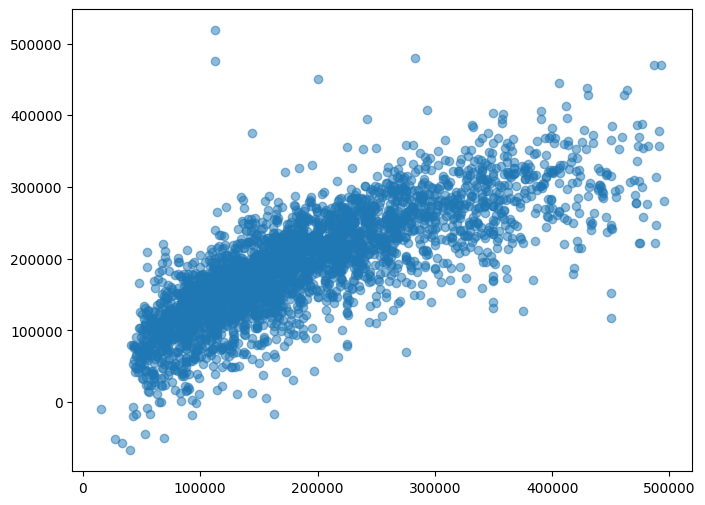

In [110]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

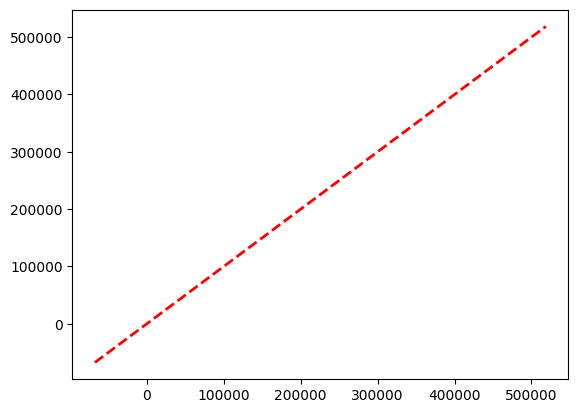

In [111]:
# Perfect prediction line (45° diagonal)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label='Perfect Prediction (45° Line)'
)


/tmp/ipykernel_737/1698095633.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


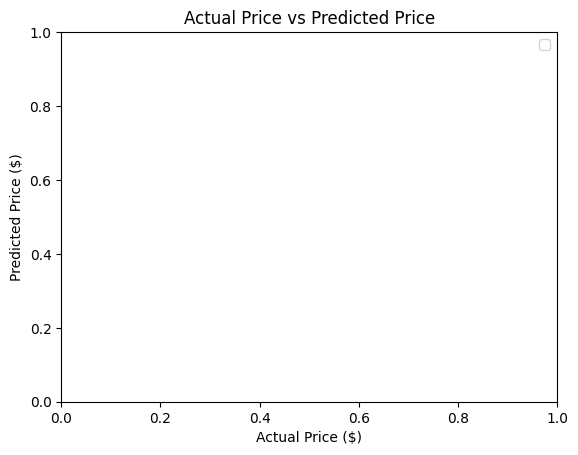

In [112]:
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Actual Price vs Predicted Price")
plt.legend()
plt.show()



In [113]:
# Calculate residuals
residuals = y_test - y_pred

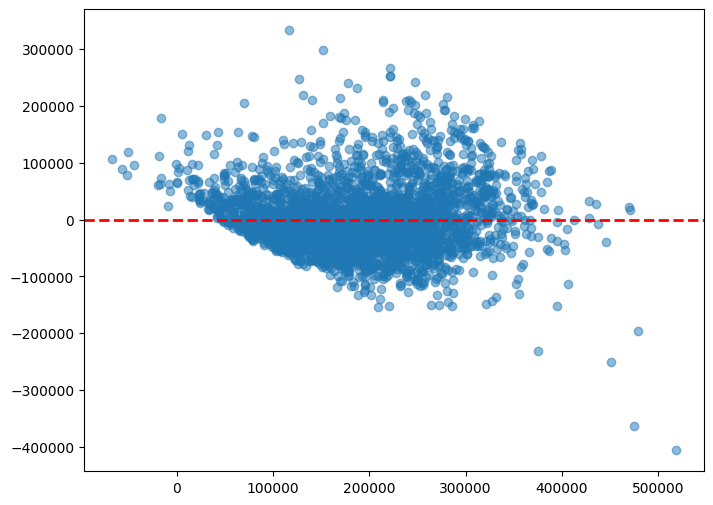

In [114]:
# Residual Plot
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=2
)

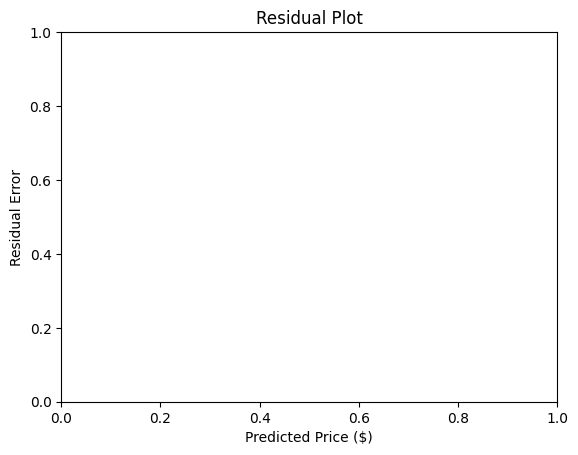

In [115]:
plt.xlabel("Predicted Price ($)")
plt.ylabel("Residual Error")
plt.title("Residual Plot")
plt.show()

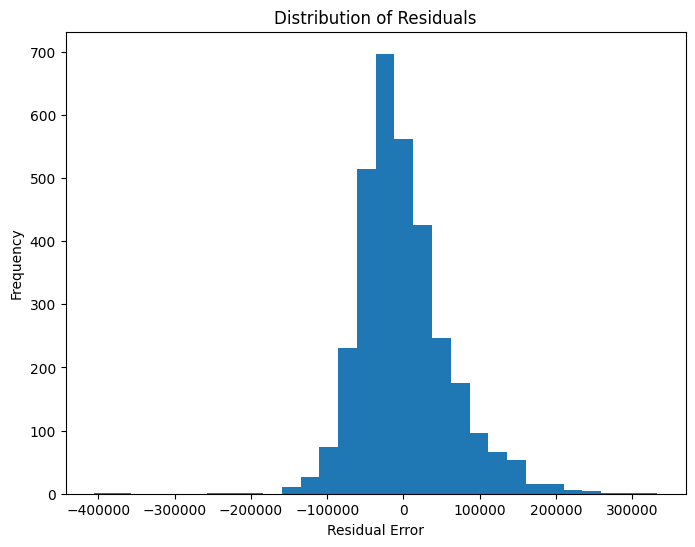

In [116]:
# Residual Distribution Histogram
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=30)

plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()